# Cardinal Buoy Classification — YOLOv8-cls Fine-tuning
Transfer learning with YOLOv8n-cls (ImageNet pretrained).  
Double augmentation: pre-augmentation ×5 (class-balanced) + YOLO internal augmentation.

In [1]:
!pip install ultralytics --quiet

IMG_SIZE = (224, 224)  # override before %run
%run setup.ipynb

import shutil, tempfile
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import confusion_matrix, classification_report
from torchvision import transforms as T
from ultralytics import YOLO

/bin/bash: line 1: pip: command not found


dataset_root : /home/elias/Documents/FISE/Projet_image2/Project datasets
DETECTION_METHOD : algo
East: 36 images


North: 59 images


South: 38 images


West: 34 images


Dataset chargé : 167 images, taille (224, 224)
Distribution   : {'East': 36, 'North': 59, 'South': 38, 'West': 34}


WARNING ⚠️ torchvision==0.26 is incompatible with torch==2.10.
Run 'pip install torchvision==0.25' to fix torchvision or 'pip install -U torch torchvision' to update both.
For a full compatibility table see https://github.com/pytorch/vision#installation


In [2]:
BATCH_SIZE = 16
EPOCHS     = 60
PATIENCE   = 10
AUG_FACTOR = 5   # base augmentation multiplier per training image

In [3]:
# Pre-augmentation transforms (applied when writing train images to disk)
# hue is kept very low: yellow/black color bands are the main class signal
augment_transform = T.Compose([
    T.ToPILImage(),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(30),
    T.ColorJitter(brightness=0.3, contrast=0.2, saturation=0.15, hue=0.04),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.85, 1.15)),
    T.RandomResizedCrop(224, scale=(0.8, 1.0)),
])


def write_fold_images(X, y, train_idx, val_idx, test_idx, fold_dir):
    """Write split images to YOLO classification folder structure.
    Val and test get original images only (no augmentation — prevents leakage).
    Train gets originals + AUG_FACTOR augmented copies, with more copies for
    minority classes to compensate for imbalance.
    """
    for split, idxs in [('val', val_idx), ('test', test_idx)]:
        for i, (img_arr, label) in enumerate(zip(X[idxs], y[idxs])):
            out = fold_dir / split / direction_names[label]
            out.mkdir(parents=True, exist_ok=True)
            Image.fromarray(img_arr).save(out / f'{i:04d}.jpg', quality=95)

    class_counts = {c: int(np.sum(y[train_idx] == c)) for c in range(4)}
    max_count    = max(class_counts.values())

    for i, (img_arr, label) in enumerate(zip(X[train_idx], y[train_idx])):
        out = fold_dir / 'train' / direction_names[label]
        out.mkdir(parents=True, exist_ok=True)
        Image.fromarray(img_arr).save(out / f'{i:04d}_orig.jpg', quality=95)
        n_aug = max(AUG_FACTOR, round(AUG_FACTOR * max_count / class_counts[label]))
        for k in range(n_aug):
            aug_img = augment_transform(img_arr)
            aug_img.save(out / f'{i:04d}_aug{k}.jpg', quality=90)

In [4]:
import time

skf              = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)
fold_accuracies  = []
fold_times       = []
all_y_true       = []
all_y_pred       = []
class_accuracies = {i: [] for i in range(4)}

print('=' * 70)
print('YOLOv8n-cls FINE-TUNING — 5-FOLD STRATIFIED CV')
print(f'Pre-augmentation ×{AUG_FACTOR} (class-balanced) + YOLO internal aug')
print('=' * 70)

for fold, (train_val_idx, test_idx) in enumerate(skf.split(X, y)):
    print(f"\n{'='*70}\nFOLD {fold+1}/{CV_FOLDS}\n{'='*70}")

    # Split train/val BEFORE augmentation — fixes the data leakage bug
    # (previous ResNet notebook augmented first then used validation_split=0.15,
    #  causing augmented copies of train images to appear in validation → val_acc=100%)
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=fold)
    rel_tr, rel_val = next(sss.split(train_val_idx, y[train_val_idx]))
    train_idx = train_val_idx[rel_tr]
    val_idx   = train_val_idx[rel_val]

    print(f'Raw train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}')

    fold_dir = Path(tempfile.mkdtemp(prefix=f'yolo_fold{fold}_'))
    write_fold_images(X, y, train_idx, val_idx, test_idx, fold_dir)

    aug_counts = {
        direction_names[c]: len(list((fold_dir / 'train' / direction_names[c]).glob('*.jpg')))
        for c in range(4)
    }
    print(f'Augmented train: {aug_counts}')

    model = YOLO('yolov8n-cls.pt')
    model.train(
        data=str(fold_dir),
        epochs=EPOCHS,
        imgsz=224,
        batch=BATCH_SIZE,
        device='cpu',
        patience=PATIENCE,
        plots=False,
        verbose=False,
        workers=0,
        project='/tmp/yolo_runs',
        name=f'fold{fold}',
        exist_ok=True,
        # YOLO internal augmentation (2nd layer on top of pre-augmented images)
        degrees=15,
        translate=0.1,
        scale=0.15,
        fliplr=0.5,
        flipud=0.3,
        hsv_h=0.02,
        hsv_s=0.4,
        hsv_v=0.3,
        erasing=0.2,
        auto_augment='randaugment',
    )

    # Load best weights saved during training
    best_pt = Path(f'/tmp/yolo_runs/fold{fold}/weights/best.pt')
    if best_pt.exists():
        model = YOLO(str(best_pt))

    # Predict on test images — use original path list to get true labels,
    # since r.path may resolve to an internal YOLO temp path
    test_images = sorted((fold_dir / 'test').rglob('*.jpg'))
    y_pred_fold, y_true_fold = [], []
    for r, img_path in zip(model.predict(source=test_images, verbose=False, stream=True), test_images):
        pred_class      = int(r.probs.top1)
        true_class_name = img_path.parent.name
        true_class      = next(k for k, v in direction_names.items() if v == true_class_name)
        y_pred_fold.append(pred_class)
        y_true_fold.append(true_class)

    # Temps de traitement d'une nouvelle image test : prediction YOLO sur une
    # image isolee (chargement + redimensionnement + inference du modele).
    _ = model.predict(source=str(test_images[0]), verbose=False)  # warm-up
    per_image_times = []
    for img_path in test_images:
        t0 = time.perf_counter()
        model.predict(source=str(img_path), verbose=False)
        per_image_times.append(time.perf_counter() - t0)
    fold_times.append(np.mean(per_image_times))

    test_acc = np.mean(np.array(y_pred_fold) == np.array(y_true_fold))
    fold_accuracies.append(test_acc)
    all_y_true.extend(y_true_fold)
    all_y_pred.extend(y_pred_fold)

    for c in range(4):
        mask = np.array(y_true_fold) == c
        if mask.sum() > 0:
            class_accuracies[c].append(
                np.mean(np.array(y_pred_fold)[mask] == np.array(y_true_fold)[mask])
            )

    print(f'Test accuracy: {test_acc:.1%} | Time/image: {fold_times[-1]*1000:.2f}ms')
    cm_fold = confusion_matrix(y_true_fold, y_pred_fold, labels=list(range(4)))
    print('Confusion matrix (rows=true, cols=pred):')
    print('  ', [direction_names[i][:1] for i in range(4)])
    for i, row in enumerate(cm_fold):
        print(f'  {direction_names[i][:1]}: {list(row)}')

    shutil.rmtree(str(fold_dir), ignore_errors=True)
    shutil.rmtree('/tmp/yolo_runs', ignore_errors=True)

print(f"\n{'='*70}")
print('FINAL RESULTS')
print(f"{'='*70}")
print(f'Mean accuracy : {np.mean(fold_accuracies):.4f} ({np.mean(fold_accuracies)*100:.1f}%)')
print(f'Std deviation : {np.std(fold_accuracies):.4f}')
print(f"Fold-by-fold  : {[f'{a*100:.1f}%' for a in fold_accuracies]}")
print(f'Mean time per image : {np.mean(fold_times)*1000:.2f} ms')
print('\nPer-class accuracy (averaged across folds):')
for c in range(4):
    if class_accuracies[c]:
        print(f'  {direction_names[c]:6s}: {np.mean(class_accuracies[c]):.1%}')
print('=' * 70)

YOLOv8n-cls FINE-TUNING — 5-FOLD STRATIFIED CV
Pre-augmentation ×5 (class-balanced) + YOLO internal aug

FOLD 1/5
Raw train: 106 | Val: 27 | Test: 34


Augmented train: {'East': 220, 'North': 228, 'South': 216, 'West': 220}


New https://pypi.org/project/ultralytics/8.4.51 available 😃 Update with 'pip install -U ultralytics'


Ultralytics 8.4.47 🚀 Python-3.11.15 torch-2.10.0 CPU (AMD Ryzen 7 5700U with Radeon Graphics)


engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/tmp/yolo_fold0_sbdmkbz6, degrees=15, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.2, exist_ok=True, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.4, hsv_v=0.3, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fold0, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspective=0.0, plots=False, pose=12.0, pretrained=True, profile=False, project=/tmp/yo

...

               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 1/1 8.9it/s 0.1s

                   all       0.63          1


Speed: 0.0ms preprocess, 3.1ms inference, 0.0ms loss, 0.0ms postprocess per image


MLflow: results logged to runs/mlflow
MLflow: disable with 'yolo settings mlflow=False'


Test accuracy: 60.6% | Time/image: 7.17ms
Confusion matrix (rows=true, cols=pred):
   ['E', 'N', 'S', 'W']
  E: [3, 0, 1, 3]
  N: [0, 7, 2, 3]
  S: [0, 0, 5, 2]
  W: [0, 1, 1, 5]

FINAL RESULTS
Mean accuracy : 0.6820 (68.2%)
Std deviation : 0.0621
Fold-by-fold  : ['73.5%', '73.5%', '72.7%', '60.6%', '60.6%']
Mean time per image : 8.03 ms

Per-class accuracy (averaged across folds):
  East  : 47.9%
  North : 73.0%
  South : 73.2%
  West  : 76.2%


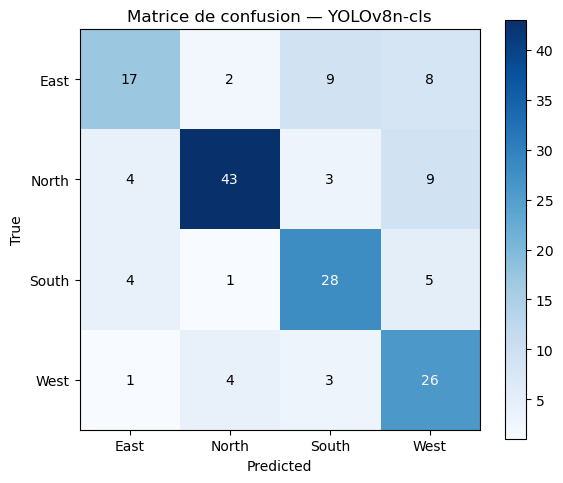

              precision    recall  f1-score   support

        East      0.654     0.472     0.548        36
       North      0.860     0.729     0.789        59
       South      0.651     0.737     0.691        38
        West      0.542     0.765     0.634        34

    accuracy                          0.683       167
   macro avg      0.677     0.676     0.666       167
weighted avg      0.703     0.683     0.683       167



In [5]:
class_names = [direction_names[i] for i in range(4)]
cm_agg = confusion_matrix(all_y_true, all_y_pred, labels=list(range(4)))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_agg, cmap='Blues', interpolation='nearest')
fig.colorbar(im, ax=ax)
ax.set(
    xticks=range(4), yticks=range(4),
    xticklabels=class_names, yticklabels=class_names,
    xlabel='Predicted', ylabel='True',
    title='Matrice de confusion — YOLOv8n-cls'
)
thresh = cm_agg.max() / 2.0
for i in range(4):
    for j in range(4):
        ax.text(j, i, cm_agg[i, j], ha='center', va='center',
                color='white' if cm_agg[i, j] > thresh else 'black')
plt.tight_layout()
plt.savefig('yolo_confusion_matrix.png', dpi=150)
plt.show()

print(classification_report(all_y_true, all_y_pred, target_names=class_names, digits=3))